# 01 Data Audit — #FeesMustFall and #EndSARS

**Purpose:** Load the raw archival datasets, inspect schema and quality, standardise both datasets into a common structure, and save reproducible audit outputs for dissertation.

**Project:** Multilingual Emotion Mining and Topic Modelling of Public Unrest on X: A Case Study of #FeesMustFall and #EndSARS.

This notebook is for **data audit and standardisation**. 

## Notebook Logic

Notebook flow:

1. Imports and environment check  
2. Project and path configuration  
3. Locate raw datasets  
4. Load Excel files  
5. Schema inspection  
6. Missing value audit  
7. Duplicate tweet ID audit  
8. Text quality audit  
9. Date range and temporal coverage audit  
10. Hashtag audit  
11. Standardise both datasets into one common schema  
12. Save audit outputs  
13. Final checklist

In [1]:
# 1. IMPORTS AND ENVIRONMENT CHECK

import sys
import os
import re
from pathlib import Path


import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 200)

print("Python executable:", sys.executable)
print("Python version:", sys.version)
print("Pandas version:", pd.__version__)
print("Current working directory:", Path.cwd())

Python executable: /mnt/c/Users/emeka/OneDrive - hull.ac.uk/Emeka_EmotionMining_project/venv/bin/python
Python version: 3.12.3 (main, Aug 14 2025, 17:47:21) [GCC 13.3.0]
Pandas version: 3.0.3
Current working directory: /mnt/c/Users/emeka/OneDrive - hull.ac.uk/Emeka_EmotionMining_project


## 1.1 Optional package installation

Run this only if Excel loading fails because `openpyxl` is missing.

In [2]:
# OPTIONAL: run only if needed
# import subprocess
# subprocess.check_call([sys.executable, "-m", "pip", "install", "openpyxl"])

In [3]:
# PROJECT AND OUTPUT PATHS

PROJECT_DIR = Path.cwd()

OUTPUT_DIR = PROJECT_DIR / "outputs" / "tables"
FIGURE_DIR = PROJECT_DIR / "outputs" / "figures"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_DIR:", PROJECT_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("FIGURE_DIR:", FIGURE_DIR)

PROJECT_DIR: /mnt/c/Users/emeka/OneDrive - hull.ac.uk/Emeka_EmotionMining_project
OUTPUT_DIR: /mnt/c/Users/emeka/OneDrive - hull.ac.uk/Emeka_EmotionMining_project/outputs/tables
FIGURE_DIR: /mnt/c/Users/emeka/OneDrive - hull.ac.uk/Emeka_EmotionMining_project/outputs/figures


## 2.1 Locate Raw Data Files

This cell will detect the two raw Excel files automatically. It checks common locations first, including project folder, `data/raw`, and WSL-mounted OneDrive paths.

In [4]:
# LOCATE RAW DATA FILES

candidate_dirs = [
    PROJECT_DIR,
    PROJECT_DIR / "data" / "raw",
    Path("/mnt/c/Users/emeka/OneDrive - hull.ac.uk/Emeka_EmotionMining_project"),
    Path("/mnt/c/Users/emeka/OneDrive - hull.ac.uk/Emeka_EmotionMining_project/data/raw"),
    Path("/mnt/c/Users/emeka/OneDrive - hull.ac.uk/DISSERTATION PROJECT/data/raw"),
    Path("/mnt/c/Users/976484/OneDrive - hull.ac.uk/DISSERTATION PROJECT/data/raw"),
]

def find_first_file(patterns, candidate_dirs):
    for folder in candidate_dirs:
        if folder.exists():
            for pattern in patterns:
                matches = list(folder.glob(pattern))
                if matches:
                    return matches[0]
    return None

ENDSARS_PATH = find_first_file(
    ["endsars.xlsx", "EndSARS.xlsx", "*endsars*.xlsx", "*EndSARS*.xlsx"],
    candidate_dirs
)

FEES_PATH = find_first_file(
    ["FeesMustFall (V MODEL CODE BOOK).xlsx", "*FeesMustFall*.xlsx", "*feesmustfall*.xlsx", "*Fees*Fall*.xlsx"],
    candidate_dirs
)

print("Auto-detected EndSARS path:", ENDSARS_PATH)
print("Auto-detected FeesMustFall path:", FEES_PATH)

print("\\nExists?")
print("EndSARS:", ENDSARS_PATH.exists() if ENDSARS_PATH else False)
print("FeesMustFall:", FEES_PATH.exists() if FEES_PATH else False)

Auto-detected EndSARS path: /mnt/c/Users/emeka/OneDrive - hull.ac.uk/Emeka_EmotionMining_project/endsars.xlsx
Auto-detected FeesMustFall path: /mnt/c/Users/emeka/OneDrive - hull.ac.uk/DISSERTATION PROJECT/data/raw/FeesMustFall (V MODEL CODE BOOK).xlsx
\nExists?
EndSARS: True
FeesMustFall: True


In [5]:
# INSPECT FEESMUSTFALL WORKBOOK SHEETS

fees_excel = pd.ExcelFile(FEES_PATH)
print("FeesMustFall workbook sheets:")
for sheet in fees_excel.sheet_names:
    print("-", sheet)

FeesMustFall workbook sheets:
- 1. FeesMustFall
- 2. 10222015_Sample
- 2.2.Campus-Based sample
- 2.3. Source frequenc per campus
- 2.4. Big Data Volume
- 3. Big Data codebook
- 5. #FMF Tweets as per campus
- 4.2 RI Map
- 4. Relative Impact
- 6.  Excluded campus narratives


In [6]:
# 5. LOAD RAW DATASETS

FEES_SHEET_NAME = "1. FeesMustFall"

endsars_df = pd.read_excel(ENDSARS_PATH)
fees_df = pd.read_excel(FEES_PATH, sheet_name=FEES_SHEET_NAME)

print("EndSARS shape:", endsars_df.shape)
print("FeesMustFall shape:", fees_df.shape)

display(endsars_df.head(3))
display(fees_df.head(3))

EndSARS shape: (131930, 9)
FeesMustFall shape: (462770, 27)


,Datetime,Tweet Id,Text,Username,location,verified,created,retweet,likes
0,2020-12-30 23:59:39+00:00,1344432997957850112,"@DannyWalta In 2020, politicians in Nig almost unwittingly killed about 40 million Nigerians through starvation, by locking up warehouses stuffed with staples. #EndSARSÂ Â indirectly opened these...",LeagueofCitize1,Nigeria,False,2020-11-30 09:20:55+00:00,1,0
1,2020-12-30 23:59:36+00:00,1344432982896110080,31-12-2020 Rounding Upâ€¦ \n\n1-1-2021 Loadingâ€¦ \n\nDear Passengers Exercise Some Patience. ðŸ™‚\n\n#TuleChallenge #Nadeco #Thiago #Klopp #BuhariTrain #Psquare #Wizkidfc #NoStoryWithGuinness #En...,Mc_Hugo92,"Lagos, Nigeria",False,2011-05-24 02:29:46+00:00,1,1
2,2020-12-30 23:59:11+00:00,1344432881486139904,#EndSARS,JarrodB19_,"Michigan, USA",False,2009-05-01 20:20:36+00:00,2,2


,date_time,tweet_id,tweet_permalink_path,user_screen_name,user_name,user_id,user_image_url,user_followers,user_following,user_created,user_tweets,user_verified,clear_text,retweets,favorites,responses,source,tweet_language,media_link,location_name,location_fullname,user_location,user_timezone,hashtags,responses_to_tweeter,mentions_of_tweeter,relative_impact
0,2015-03-21 14:28:07,5.792884e+17,https://twitter.com/SkhumbuzoTuswa/status/579288381793964032,SkhumbuzoTuswa,Hectare Peterson ?,70659387.0,https://pbs.twimg.com/profile_images/945920556066574337/0XejyHy__400x400.jpg,1308.0,585.0,2009-09-01 11:42:45,20493.0,0.0,Priorities?? #FeesMustFall RT @informer_sa: UCT's #RhodesMustFall campaign gains momentum http://t.co/1eIIX3mWZx http://t.co/5FY78MKzjI,4,5.0,1.0,TweetDeck,en,NaN,NaN,NaN,"Braamfontein, South Africa",Africa/Johannesburg,#feesmustfall #rhodesmustfall,4.0,10.0,1.3115
1,2015-04-07 04:31:56,5.852989e+17,https://twitter.com/SSSIBIYA/status/585298939856977920,SSSIBIYA,SIMANGALISO S SIBIYA,215945807.0,https://pbs.twimg.com/profile_images/850036284261371907/eBXP1ciA_400x400.jpg,370.0,1785.0,2010-11-15 11:08:08,2885.0,0.0,#FEESMustFall that will make sense to me. Free quality education in our lifetime,2,4.0,NaN,Twitter for BlackBerryÂ®,en,NaN,Durban,NaN,Nkandla eMagidini,Athens,#feesmustfall,NaN,NaN,0.6557
2,2015-10-13 17:07:34,6.539804e+17,https://twitter.com/MadVocate_/status/653980410557427712,MadVocate_,THUMA MINA,438454672.0,https://pbs.twimg.com/profile_images/964008933210849280/kFyAt5Gz_400x400.jpg,7748.0,892.0,2011-12-16 16:16:09,216781.0,0.0,Now it is time for me to mobilize Wits students. Tomorrow at 12pm we meet at West campus #FeesMustFall http://t.co/9aO790bbIr,6,1.0,NaN,Twitter Web Client,en,https://pbs.twimg.com/media/CRNntoQUYAEO8YE.png,NaN,NaN,South Africa,Hawaii,#feesmustfall,18.0,57.0,1.9672


## 5.1 Schema Inspection

Confirm column structure of both datasets before transformation.

In [7]:
# 6. SCHEMA INSPECTION

print("EndSARS columns:")
print(endsars_df.columns.tolist())

print("\nFeesMustFall columns:")
print(fees_df.columns.tolist())

print("\nEndSARS data types:")
display(endsars_df.dtypes.reset_index().rename(columns={"index": "column", 0: "dtype"}))

print("\nFeesMustFall data types:")
display(fees_df.dtypes.reset_index().rename(columns={"index": "column", 0: "dtype"}))

EndSARS columns:
['Datetime', 'Tweet Id', 'Text', 'Username', 'location', 'verified', 'created', 'retweet', 'likes']

FeesMustFall columns:
['date_time', 'tweet_id', 'tweet_permalink_path', 'user_screen_name', 'user_name', 'user_id', 'user_image_url', 'user_followers', 'user_following', 'user_created', 'user_tweets', 'user_verified', 'clear_text', 'retweets', 'favorites', 'responses', 'source', 'tweet_language', 'media_link', 'location_name', 'location_fullname', 'user_location', 'user_timezone', 'hashtags', 'responses_to_tweeter', 'mentions_of_tweeter', 'relative_impact']

EndSARS data types:


,column,dtype
0,Datetime,str
1,Tweet Id,int64
2,Text,str
3,Username,str
4,location,object
5,verified,bool
6,created,str
7,retweet,int64
8,likes,int64



FeesMustFall data types:


,column,dtype
0,date_time,datetime64[us]
1,tweet_id,float64
2,tweet_permalink_path,str
3,user_screen_name,object
4,user_name,object
5,user_id,float64
6,user_image_url,str
7,user_followers,float64
8,user_following,float64
9,user_created,datetime64[us]


In [8]:
# 6.1 REQUIRED COLUMN CHECK

required_endsars_cols = ["Datetime", "Tweet Id", "Text", "location"]
required_fees_cols = ["date_time", "tweet_id", "clear_text", "user_location", "tweet_language"]

missing_endsars_cols = [col for col in required_endsars_cols if col not in endsars_df.columns]
missing_fees_cols = [col for col in required_fees_cols if col not in fees_df.columns]

print("Missing EndSARS required columns:", missing_endsars_cols)
print("Missing FeesMustFall required columns:", missing_fees_cols)

assert len(missing_endsars_cols) == 0, f"Missing EndSARS columns: {missing_endsars_cols}"
assert len(missing_fees_cols) == 0, f"Missing FeesMustFall columns: {missing_fees_cols}"

Missing EndSARS required columns: []
Missing FeesMustFall required columns: []


## 6. Missing Value Audit

This records missingness by column. Missing location values are expected because X/Twitter location metadata is optional and not central to the research questions.

In [9]:
# MISSING VALUE AUDIT

def missing_value_report(df, dataset_name):
    report = df.isna().sum().reset_index()
    report.columns = ["column", "missing_count"]
    report["missing_percent"] = (report["missing_count"] / len(df) * 100).round(2)
    report["dataset"] = dataset_name
    return report[["dataset", "column", "missing_count", "missing_percent"]].sort_values(
        "missing_percent", ascending=False
    )

endsars_missing = missing_value_report(endsars_df, "EndSARS")
fees_missing = missing_value_report(fees_df, "FeesMustFall")

display(endsars_missing)
display(fees_missing)

endsars_missing.to_csv(OUTPUT_DIR / "01_endsars_missing_values.csv", index=False)
fees_missing.to_csv(OUTPUT_DIR / "01_feesmustfall_missing_values.csv", index=False)

,dataset,column,missing_count,missing_percent
4,EndSARS,location,34208,25.93
0,EndSARS,Datetime,0,0.00
1,EndSARS,Tweet Id,0,0.00
2,EndSARS,Text,0,0.00
3,EndSARS,Username,0,0.00
5,EndSARS,verified,0,0.00
6,EndSARS,created,0,0.00
7,EndSARS,retweet,0,0.00
8,EndSARS,likes,0,0.00


,dataset,column,missing_count,missing_percent
20,FeesMustFall,location_fullname,462770,100.00
15,FeesMustFall,responses,452638,97.81
19,FeesMustFall,location_name,435917,94.20
18,FeesMustFall,media_link,397420,85.88
24,FeesMustFall,responses_to_tweeter,302721,65.42
25,FeesMustFall,mentions_of_tweeter,231571,50.04
22,FeesMustFall,user_timezone,170380,36.82
21,FeesMustFall,user_location,59945,12.95
23,FeesMustFall,hashtags,2509,0.54
4,FeesMustFall,user_name,40,0.01


## 7. Duplicate Tweet ID Audit

Duplicates are assessed using tweet IDs because duplicate IDs indicate duplicated records.

In [10]:
# DUPLICATE TWEET ID AUDIT


def duplicate_id_report(df, id_col, dataset_name):
    total_rows = len(df)
    missing_ids = df[id_col].isna().sum()
    duplicate_ids = df[id_col].duplicated().sum()
    unique_ids = df[id_col].nunique(dropna=True)

    return {
        "dataset": dataset_name,
        "total_rows": total_rows,
        "missing_tweet_ids": missing_ids,
        "unique_tweet_ids": unique_ids,
        "duplicate_tweet_ids": duplicate_ids,
        "duplicate_percent": round((duplicate_ids / total_rows) * 100, 4)
    }

duplicate_report = pd.DataFrame([
    duplicate_id_report(fees_df, "tweet_id", "FeesMustFall"),
    duplicate_id_report(endsars_df, "Tweet Id", "EndSARS")
])

display(duplicate_report)
duplicate_report.to_csv(OUTPUT_DIR / "01_duplicate_id_report.csv", index=False)

,dataset,total_rows,missing_tweet_ids,unique_tweet_ids,duplicate_tweet_ids,duplicate_percent
0,FeesMustFall,462770,1,462730,39,0.0084
1,EndSARS,131930,0,131888,42,0.0318


## 8. Text Quality Audit

This records text length and word count distributions before preprocessing. Filtering belongs in `02_preprocessing.ipynb`.

In [11]:
# TEXT QUALITY AUDIT

def add_text_quality_features(df, text_col):
    temp = df.copy()
    temp["_text_for_audit"] = temp[text_col].astype("string")
    temp["_text_length"] = temp["_text_for_audit"].str.len()
    temp["_word_count"] = temp["_text_for_audit"].str.split().str.len()
    return temp

fees_audit = add_text_quality_features(fees_df, "clear_text")
endsars_audit = add_text_quality_features(endsars_df, "Text")

def text_quality_summary(temp, dataset_name):
    return {
        "dataset": dataset_name,
        "rows": len(temp),
        "missing_text": temp["_text_for_audit"].isna().sum(),
        "empty_text_after_strip": (temp["_text_for_audit"].fillna("").str.strip() == "").sum(),
        "duplicate_texts": temp["_text_for_audit"].duplicated().sum(),
        "mean_text_length": temp["_text_length"].mean(),
        "median_text_length": temp["_text_length"].median(),
        "min_text_length": temp["_text_length"].min(),
        "max_text_length": temp["_text_length"].max(),
        "mean_word_count": temp["_word_count"].mean(),
        "median_word_count": temp["_word_count"].median(),
        "min_word_count": temp["_word_count"].min(),
        "max_word_count": temp["_word_count"].max()
    }

text_quality_report = pd.DataFrame([
    text_quality_summary(fees_audit, "FeesMustFall"),
    text_quality_summary(endsars_audit, "EndSARS")
])

display(text_quality_report)
text_quality_report.to_csv(OUTPUT_DIR / "01_text_quality_report.csv", index=False)

,dataset,rows,missing_text,empty_text_after_strip,duplicate_texts,mean_text_length,median_text_length,min_text_length,max_text_length,mean_word_count,median_word_count,min_word_count,max_word_count
0,FeesMustFall,462770,7,7,10666,103.995285,112.0,13,476,13.789266,14.0,1,56
1,EndSARS,131930,0,0,8420,143.563829,117.0,4,1626,18.546805,15.0,1,88


In [12]:
# 9.1 TEXT LENGTH DESCRIPTIVE STATISTICS

fees_text_describe = fees_audit["_text_length"].describe().reset_index()
fees_text_describe.columns = ["statistic", "FeesMustFall_text_length"]

endsars_text_describe = endsars_audit["_text_length"].describe().reset_index()
endsars_text_describe.columns = ["statistic", "EndSARS_text_length"]

text_length_describe = fees_text_describe.merge(endsars_text_describe, on="statistic")

display(text_length_describe)
text_length_describe.to_csv(OUTPUT_DIR / "01_text_length_descriptive_statistics.csv", index=False)

,statistic,FeesMustFall_text_length,EndSARS_text_length
0,count,462763.0,131930.0
1,mean,103.995285,143.563829
2,std,33.968796,111.989765
3,min,13.0,4.0
4,25%,79.0,58.0
5,50%,112.0,117.0
6,75%,135.0,218.0
7,max,476.0,1626.0


## 9. Date Range and Temporal Coverage Audit

This confirms whether each dataset covers a suitable protest period for later phase-based analysis.

In [13]:
# 10. DATE RANGE AUDIT

fees_dates = pd.to_datetime(fees_df["date_time"], errors="coerce")
endsars_dates = pd.to_datetime(endsars_df["Datetime"], errors="coerce", utc=True)

date_report = pd.DataFrame([
    {
        "dataset": "FeesMustFall",
        "missing_or_invalid_dates": fees_dates.isna().sum(),
        "start_date": fees_dates.min(),
        "end_date": fees_dates.max(),
        "unique_days": fees_dates.dt.date.nunique()
    },
    {
        "dataset": "EndSARS",
        "missing_or_invalid_dates": endsars_dates.isna().sum(),
        "start_date": endsars_dates.min(),
        "end_date": endsars_dates.max(),
        "unique_days": endsars_dates.dt.date.nunique()
    }
])

display(date_report)
date_report.to_csv(OUTPUT_DIR / "01_date_range_report.csv", index=False)

,dataset,missing_or_invalid_dates,start_date,end_date,unique_days
0,FeesMustFall,1,2015-03-21 14:28:07,2016-12-31 23:25:02,448
1,EndSARS,0,2020-06-03 17:45:03+00:00,2020-12-30 23:59:39+00:00,128


In [14]:
# TEMPORAL DISTRIBUTION BY MONTH

fees_monthly = pd.DataFrame({
    "movement": "FeesMustFall",
    "date": pd.to_datetime(fees_df["date_time"], errors="coerce", utc=True)
})

endsars_monthly = pd.DataFrame({
    "movement": "EndSARS",
    "date": pd.to_datetime(endsars_df["Datetime"], errors="coerce", utc=True)
})

monthly_df = pd.concat(
    [fees_monthly, endsars_monthly],
    ignore_index=True
)

monthly_df = monthly_df.dropna(subset=["date"]).copy()

# Force date column to proper datetime type after concatenation
monthly_df["date"] = pd.to_datetime(
    monthly_df["date"],
    errors="coerce",
    utc=True
)

monthly_df["month"] = monthly_df["date"].dt.to_period("M").astype(str)

monthly_counts = (
    monthly_df
    .groupby(["movement", "month"])
    .size()
    .reset_index(name="tweet_count")
)

display(monthly_counts.head())

monthly_counts.to_csv(
    OUTPUT_DIR / "monthly_tweet_counts.csv",
    index=False
)

print("Saved monthly tweet counts.")

/tmp/ipykernel_3999/4039196000.py:27: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  monthly_df["month"] = monthly_df["date"].dt.to_period("M").astype(str)


,movement,month,tweet_count
0,EndSARS,2020-06,2993
1,EndSARS,2020-07,6624
2,EndSARS,2020-08,2703
3,EndSARS,2020-09,17681
4,EndSARS,2020-10,90003


Saved monthly tweet counts.


## 10. Hashtag Audit

Hashtags are thematically meaningful in protest discourse and should be preserved for preprocessing and topic modelling.

In [15]:
# 11. HASHTAG AUDIT


def extract_hashtags(text):
    if pd.isna(text):
        return []
    return re.findall(r"#\w+", str(text).lower())

def hashtag_report(df, text_col, dataset_name, top_n=30):
    hashtags = df[text_col].apply(extract_hashtags).explode().dropna()
    report = hashtags.value_counts().head(top_n).reset_index()
    report.columns = ["hashtag", "count"]
    report["dataset"] = dataset_name
    return report[["dataset", "hashtag", "count"]]

fees_hashtags = hashtag_report(fees_df, "clear_text", "FeesMustFall")
endsars_hashtags = hashtag_report(endsars_df, "Text", "EndSARS")

display(fees_hashtags)
display(endsars_hashtags)

fees_hashtags.to_csv(OUTPUT_DIR / "01_feesmustfall_top_hashtags.csv", index=False)
endsars_hashtags.to_csv(OUTPUT_DIR / "01_endsars_top_hashtags.csv", index=False)

,dataset,hashtag,count
0,FeesMustFall,#feesmustfall,466468
1,FeesMustFall,#nationalshutdown,26790
2,FeesMustFall,#southafrica,14840
3,FeesMustFall,#wits,11771
4,FeesMustFall,#fees2017,11029
5,FeesMustFall,#unionbuilding,6647
6,FeesMustFall,#ancmustfall,5361
7,FeesMustFall,#zumamustfall,4424
8,FeesMustFall,#asinamali,4314
9,FeesMustFall,#leadership,4206


,dataset,hashtag,count
0,EndSARS,#endsars,155834
1,EndSARS,#endsarsnow,10847
2,EndSARS,#endpolicebrutality,8475
3,EndSARS,#endbadgoveranceinnigeria,8207
4,EndSARS,#bursturhead,4790
5,EndSARS,#endsarsimmediately,4295
6,EndSARS,#endsarsprotests,3640
7,EndSARS,#endpolicebrutalitynow,3287
8,EndSARS,#endpolicebrutalityinnigeranow,3128
9,EndSARS,#endpolicebrutalityinnigera,2881


## 11. Existing Language Metadata Audit

FeesMustFall includes a `tweet_language` column. EndSARS does not include an equivalent language column, so language detection is performed later in `03_language_detection.ipynb`.

In [16]:
# 12. EXISTING LANGUAGE METADATA AUDIT

fees_existing_language = (
    fees_df["tweet_language"]
    .value_counts(dropna=False)
    .reset_index()
)

fees_existing_language.columns = ["existing_language", "count"]
fees_existing_language["percentage"] = (
    fees_existing_language["count"] / len(fees_df) * 100
).round(2)

display(fees_existing_language.head(30))
fees_existing_language.to_csv(OUTPUT_DIR / "01_feesmustfall_existing_language_distribution.csv", index=False)

print("EndSARS raw language column present?:", any("lang" in col.lower() for col in endsars_df.columns))

,existing_language,count,percentage
0,en,407318,88.02
1,und,36030,7.79
2,in,3882,0.84
3,nl,3321,0.72
4,tl,3319,0.72
5,ht,1137,0.25
6,es,972,0.21
7,et,904,0.20
8,de,809,0.17
9,fr,625,0.14


EndSARS raw language column present?: False


## 12. Dataset Standardisation

Both datasets are converted into a common schema: `movement`, `tweet_id`, `date`, `raw_text`, `location`, and `existing_language`.

In [17]:
# STANDARDISE DATASETS

def tweet_id_to_string(series):
    # Convert tweet IDs to string while preserving missing values as NA.
    numeric = pd.to_numeric(series, errors="coerce")
    return numeric.round(0).astype("Int64").astype("string")

fees_standard = pd.DataFrame({
    "movement": "FeesMustFall",
    "tweet_id": tweet_id_to_string(fees_df["tweet_id"]),
    "date": pd.to_datetime(fees_df["date_time"], errors="coerce", utc=True),
    "raw_text": fees_df["clear_text"].astype("string"),
    "location": fees_df["user_location"].astype("string"),
    "existing_language": fees_df["tweet_language"].astype("string")
})

endsars_standard = pd.DataFrame({
    "movement": "EndSARS",
    "tweet_id": tweet_id_to_string(endsars_df["Tweet Id"]),
    "date": pd.to_datetime(endsars_df["Datetime"], errors="coerce", utc=True),
    "raw_text": endsars_df["Text"].astype("string"),
    "location": endsars_df["location"].astype("string"),
    "existing_language": pd.Series([pd.NA] * len(endsars_df), dtype="string")
})

combined_df = pd.concat([fees_standard, endsars_standard], ignore_index=True)

print("Fees standard shape:", fees_standard.shape)
print("EndSARS standard shape:", endsars_standard.shape)
print("Combined standardised shape:", combined_df.shape)

display(combined_df.head())
display(combined_df.tail())

Fees standard shape: (462770, 6)
EndSARS standard shape: (131930, 6)
Combined standardised shape: (594700, 6)


,movement,tweet_id,date,raw_text,location,existing_language
0,FeesMustFall,579288381793964032,2015-03-21 14:28:07+00:00,Priorities?? #FeesMustFall RT @informer_sa: UCT's #RhodesMustFall campaign gains momentum http://t.co/1eIIX3mWZx http://t.co/5FY78MKzjI,"Braamfontein, South Africa",en
1,FeesMustFall,585298939856977024,2015-04-07 04:31:56+00:00,#FEESMustFall that will make sense to me. Free quality education in our lifetime,Nkandla eMagidini,en
2,FeesMustFall,653980410557426944,2015-10-13 17:07:34+00:00,Now it is time for me to mobilize Wits students. Tomorrow at 12pm we meet at West campus #FeesMustFall http://t.co/9aO790bbIr,South Africa,en
3,FeesMustFall,653981909983300992,2015-10-13 17:13:32+00:00,Residence is going up by over 9% yet I always walk up 18 flights of stairs because lifts don't work at res. #FeesMustFall,South Africa,en
4,FeesMustFall,653982244420381952,2015-10-13 17:14:52+00:00,Tomorrow is D-Day. Sikhathele! #FeesMustFall http://t.co/JalbjHoPJL,South Africa,en


,movement,tweet_id,date,raw_text,location,existing_language
594695,EndSARS,1268257796413400064,2020-06-03 19:06:36+00:00,@AsiwajuLerry #saynotorape\n#EndSARS,"oyo state, ibadan.",<NA>
594696,EndSARS,1268256585853400064,2020-06-03 19:01:47+00:00,"This whole Somto false accusation, and now Dbanj, Peruzzi being accused. Hope it doesn't water down this recent revolutionary fight against rape. For now lets focus on #JusticeForUwa #JusticeForBa...",King's Landing,<NA>
594697,EndSARS,1268247130575109888,2020-06-03 18:24:13+00:00,We are tired of all this Hash tags.. #SayNoToRape #BlackLivesMatter #StopViolence #Racism #SayNoToRapist #NoJusticeNoPeace #NoToTribalism #ICantBreathe #NoToPoliceBrutality #EndSars #JusticeforRin...,Africa,<NA>
594698,EndSARS,1268243295504920064,2020-06-03 18:08:59+00:00,@054durin @Mayokeezybeatz @funshographix @Mayokeezybeatz,Nigeria,<NA>
594699,EndSARS,1268237272220140032,2020-06-03 17:45:03+00:00,"@Tweetestboi_ph @JulietDukari Bro na, I didn't do anything na\nSee, you made it about something else not me, then you refused to answer my question \nBlacks in America are killed by white cops for...","Rivers, Nigeria",<NA>


In [18]:
# STANDARDISED CORPUS QUALITY CHECK

standardised_summary = combined_df.groupby("movement").agg(
    rows=("raw_text", "count"),
    unique_tweet_ids=("tweet_id", "nunique"),
    duplicate_tweet_ids=("tweet_id", lambda x: x.duplicated().sum()),
    missing_text=("raw_text", lambda x: x.isna().sum()),
    missing_dates=("date", lambda x: x.isna().sum()),
    missing_locations=("location", lambda x: x.isna().sum()),
    start_date=("date", "min"),
    end_date=("date", "max")
).reset_index()

display(standardised_summary)
standardised_summary.to_csv(OUTPUT_DIR / "01_standardised_corpus_summary.csv", index=False)

,movement,rows,unique_tweet_ids,duplicate_tweet_ids,missing_text,missing_dates,missing_locations,start_date,end_date
0,EndSARS,131930,131888,42,0,0,34208,2020-06-03 17:45:03+00:00,2020-12-30 23:59:39+00:00
1,FeesMustFall,462763,462730,39,7,1,59945,2015-03-21 14:28:07+00:00,2016-12-31 23:25:02+00:00


## 13. Dissertation Audit Summary

This table combines the core audit findings that can be reported in the Methodology/Data section.

In [30]:
# FINAL AUDIT SUMMARY TABLE

audit_summary = (
    duplicate_report
    .merge(text_quality_report, on="dataset", how="left")
    .merge(date_report, on="dataset", how="left")
)

audit_summary = audit_summary[
    [
        "dataset",
        "total_rows",
        "unique_tweet_ids",
        "duplicate_tweet_ids",
        "duplicate_percent",
        "missing_text",
        "mean_text_length",
        "median_text_length",
        "min_text_length",
        "max_text_length",
        "mean_word_count",
        "median_word_count",
        "start_date",
        "end_date",
        "unique_days"
    ]
]
print(audit_summary.shape)
display(audit_summary)
audit_summary.to_csv(OUTPUT_DIR / "data_audit_summary.csv", index=False)

(2, 15)


,dataset,total_rows,unique_tweet_ids,duplicate_tweet_ids,duplicate_percent,missing_text,mean_text_length,median_text_length,min_text_length,max_text_length,mean_word_count,median_word_count,start_date,end_date,unique_days
0,FeesMustFall,462770,462730,39,0.0084,7,103.995285,112.0,13,476,13.789266,14.0,2015-03-21 14:28:07,2016-12-31 23:25:02,448
1,EndSARS,131930,131888,42,0.0318,0,143.563829,117.0,4,1626,18.546805,15.0,2020-06-03 17:45:03+00:00,2020-12-30 23:59:39+00:00,128


## 14. Save Standardised Corpus

This file is the input to `02_preprocessing.ipynb`.

In [20]:
# SAVE STANDARDISED CORPUS

combined_output_path = OUTPUT_DIR / "combined_raw_audit_dataset.csv"

combined_df.to_csv(combined_output_path, index=False, encoding="utf-8")

print("Saved standardised corpus to:")
print(combined_output_path)

print("File exists:", combined_output_path.exists())
print("Rows saved:", len(combined_df))

Saved standardised corpus to:
/mnt/c/Users/emeka/OneDrive - hull.ac.uk/Emeka_EmotionMining_project/outputs/tables/combined_raw_audit_dataset.csv
File exists: True
Rows saved: 594700


## 15. Optional Audit Figures

These figures are useful for the dissertation appendix or methodology chapter.

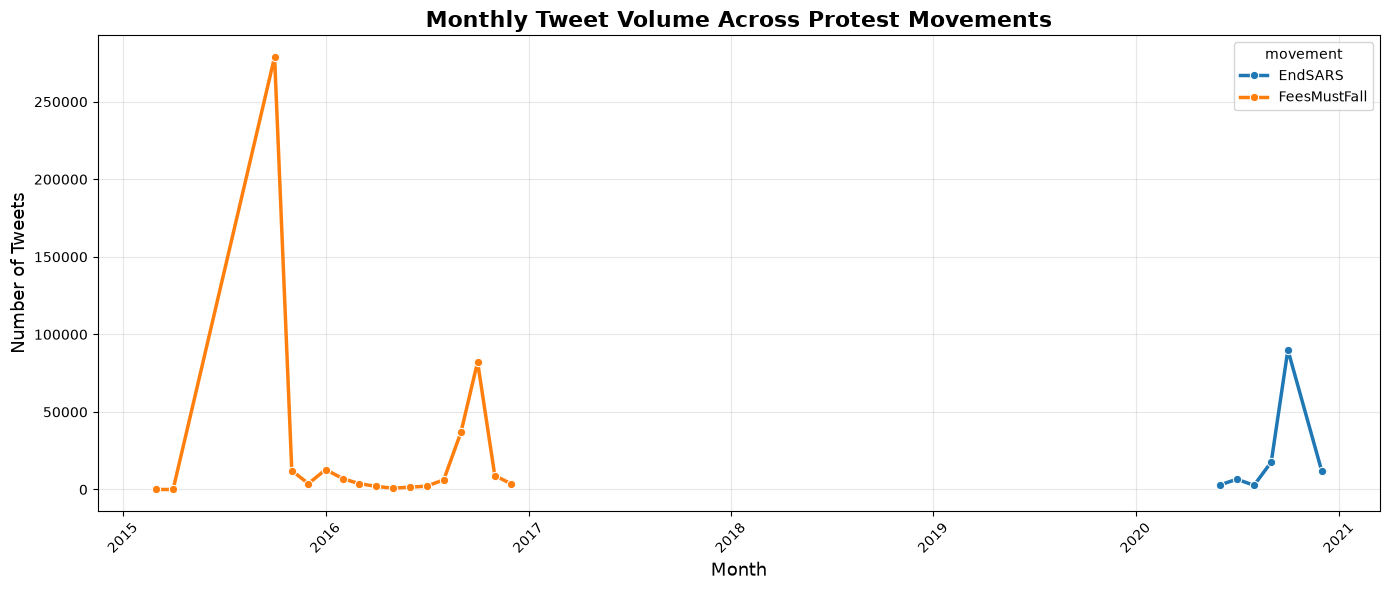

Saved figure: /mnt/c/Users/emeka/OneDrive - hull.ac.uk/Emeka_EmotionMining_project/outputs/figures/01_monthly_tweet_volume.png


In [21]:
# OPTIONAL FIGURE: MONTHLY TWEET VOLUME

if not monthly_counts.empty:
    plot_monthly = monthly_counts.copy()
    plot_monthly["month"] = pd.to_datetime(plot_monthly["month"], errors="coerce")

    plt.figure(figsize=(14, 6))

    sns.lineplot(
        data=plot_monthly,
        x="month",
        y="tweet_count",
        hue="movement",
        marker="o",
        linewidth=2.5
    )

    plt.title(
        "Monthly Tweet Volume Across Protest Movements",
        fontsize=16,
        weight="bold"
    )

    plt.xlabel("Month", fontsize=13)
    plt.ylabel("Number of Tweets", fontsize=13)

    plt.xticks(rotation=45)
    plt.grid(alpha=0.3)

    plt.tight_layout()

    fig_path = FIGURE_DIR / "01_monthly_tweet_volume.png"

    plt.savefig(
        fig_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print("Saved figure:", fig_path)

In [25]:
# CREATE TEXT LENGTH COLUMNS

fees_df["_text_length"] = (
    fees_df["clear_text"]
    .astype(str)
    .str.len()
)

endsars_df["_text_length"] = (
    endsars_df["Text"]
    .astype(str)
    .str.len()
)

print("Fees text length column created:", "_text_length" in fees_df.columns)
print("EndSARS text length column created:", "_text_length" in endsars_df.columns)

Fees text length column created: True
EndSARS text length column created: True


In [26]:
# CREATE DATAFRAME FOR TEXT LENGTH VISUALISATIONS

plot_df = pd.DataFrame({
    "movement": (
        ["FeesMustFall"] * len(fees_df) +
        ["EndSARS"] * len(endsars_df)
    ),

    "text_length": pd.concat([
        fees_df["_text_length"],
        endsars_df["_text_length"]
    ], ignore_index=True)
})

plot_df = plot_df.dropna()

# Cap extremely long tweets for visualisation only
plot_df["text_length_capped"] = (
    plot_df["text_length"]
    .clip(upper=500)
)

print(plot_df.shape)

display(plot_df.head())

(594693, 3)


,movement,text_length,text_length_capped
0,FeesMustFall,135.0,135.0
1,FeesMustFall,80.0,80.0
2,FeesMustFall,125.0,125.0
3,FeesMustFall,121.0,121.0
4,FeesMustFall,67.0,67.0


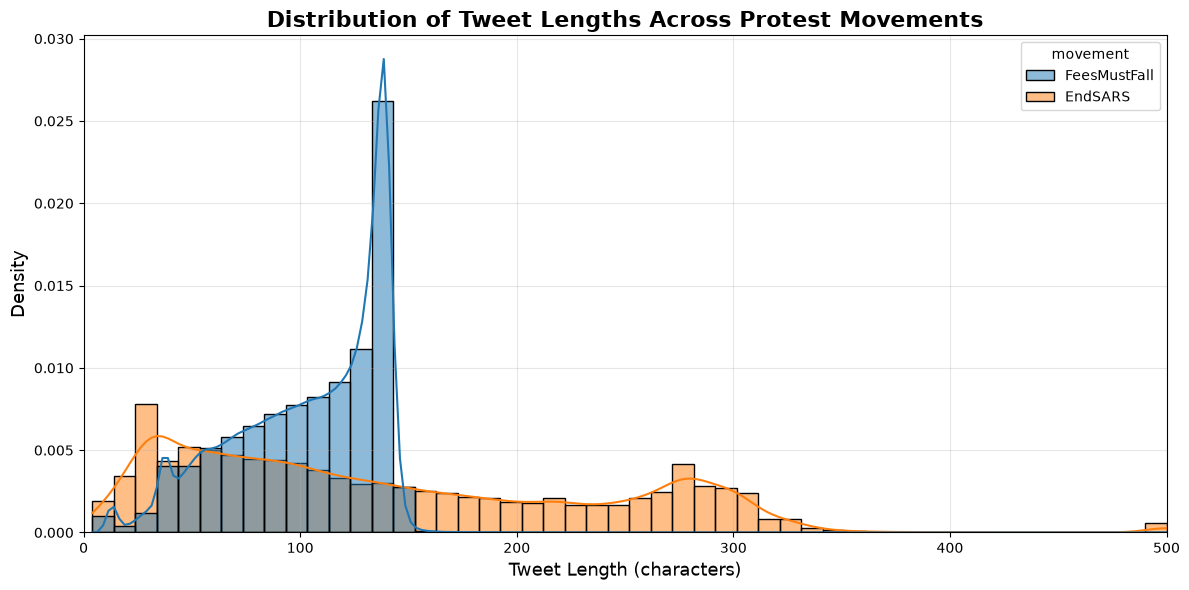

Saved figure: /mnt/c/Users/emeka/OneDrive - hull.ac.uk/Emeka_EmotionMining_project/outputs/figures/01_text_length_distribution.png


In [27]:
# FIGURE: TEXT LENGTH DISTRIBUTION
# Distinction-level visualisation

plt.figure(figsize=(12, 6))

sns.histplot(
    data=plot_df,
    x="text_length_capped",
    hue="movement",
    bins=50,
    kde=True,
    stat="density",
    common_norm=False,
    alpha=0.5
)

plt.title(
    "Distribution of Tweet Lengths Across Protest Movements",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Tweet Length (characters)", fontsize=13)
plt.ylabel("Density", fontsize=13)

plt.grid(alpha=0.3)

plt.xlim(0, 500)

plt.tight_layout()

fig_path = FIGURE_DIR / "01_text_length_distribution.png"

plt.savefig(
    fig_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved figure:", fig_path)

## 16. Final Checklist

Before moving to `02_preprocessing.ipynb`, confirm all expected outputs exist.

In [28]:
# 18. FINAL CHECKLIST

expected_outputs = [
    OUTPUT_DIR / "01_endsars_missing_values.csv",
    OUTPUT_DIR / "01_feesmustfall_missing_values.csv",
    OUTPUT_DIR / "01_duplicate_id_report.csv",
    OUTPUT_DIR / "01_text_quality_report.csv",
    OUTPUT_DIR / "01_date_range_report.csv",
    OUTPUT_DIR / "01_monthly_tweet_counts.csv",
    OUTPUT_DIR / "01_feesmustfall_top_hashtags.csv",
    OUTPUT_DIR / "01_endsars_top_hashtags.csv",
    OUTPUT_DIR / "01_feesmustfall_existing_language_distribution.csv",
    OUTPUT_DIR / "01_standardised_corpus_summary.csv",
    OUTPUT_DIR / "data_audit_summary.csv",
    OUTPUT_DIR / "combined_raw_audit_dataset.csv",
]

print("DATA AUDIT COMPLETE")
print("===================")
print("Project directory:", PROJECT_DIR)
print("Combined rows:", len(combined_df))
print("\nOutput files:")

for file in expected_outputs:
    print(file.name, "✓" if file.exists() else "MISSING")

print("\nNext notebook: 02_preprocessing.ipynb")

DATA AUDIT COMPLETE
Project directory: /mnt/c/Users/emeka/OneDrive - hull.ac.uk/Emeka_EmotionMining_project
Combined rows: 594700

Output files:
01_endsars_missing_values.csv ✓
01_feesmustfall_missing_values.csv ✓
01_duplicate_id_report.csv ✓
01_text_quality_report.csv ✓
01_date_range_report.csv ✓
01_monthly_tweet_counts.csv MISSING
01_feesmustfall_top_hashtags.csv ✓
01_endsars_top_hashtags.csv ✓
01_feesmustfall_existing_language_distribution.csv ✓
01_standardised_corpus_summary.csv ✓
data_audit_summary.csv ✓
combined_raw_audit_dataset.csv ✓

Next notebook: 02_preprocessing.ipynb


In [31]:
# SAVE REMAINING DATA AUDIT OUTPUTS

audit_summary.to_csv(
    OUTPUT_DIR / "dta_audit_summary.csv",
    index=False
)

monthly_counts.to_csv(
    OUTPUT_DIR / "monthly_tweet_counts.csv",
    index=False
)

print("Saved tables:")
print(OUTPUT_DIR / "data_audit_summary.csv")
print(OUTPUT_DIR / "monthly_tweet_counts.csv")
print(OUTPUT_DIR / "combined_raw_audit_dataset.csv")

Saved tables:
/mnt/c/Users/emeka/OneDrive - hull.ac.uk/Emeka_EmotionMining_project/outputs/tables/data_audit_summary.csv
/mnt/c/Users/emeka/OneDrive - hull.ac.uk/Emeka_EmotionMining_project/outputs/tables/monthly_tweet_counts.csv
/mnt/c/Users/emeka/OneDrive - hull.ac.uk/Emeka_EmotionMining_project/outputs/tables/combined_raw_audit_dataset.csv


## Data Audit Conclusions

The data audit revealed substantial differences between the two protest datasets. The #FeesMustFall corpus contained 462,763 tweets spanning March 2015 to December 2016, whereas the #EndSARS corpus contained 131,930 tweets collected between June and December 2020.

Both datasets exhibited relatively low levels of duplicate tweet identifiers and acceptable levels of missingness. Missing values were primarily associated with optional metadata fields such as location information and media links and were therefore retained for subsequent analysis.

Text quality assessment demonstrated considerable variation in tweet lengths, with #EndSARS tweets generally exhibiting longer and more diverse textual content than #FeesMustFall tweets. This suggests differences in communicative practices across movements, with #EndSARS discourse containing more elaborate narrative and testimonial content.

The audit further identified multilingual characteristics within the corpora, particularly within the #FeesMustFall dataset, thereby justifying the adoption of a multilingual analytical pipeline. Overall, the datasets were deemed suitable for subsequent preprocessing, language identification, emotion detection, and topic modelling stages.
